## SMS Span detector

* https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from PIL import Image

In [3]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [4]:
df = df.dropna(how="any", axis=1).copy()
df.columns = ["target", "message"]

df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
balance_counts = df.groupby("target")["target"].agg("count").values
balance_counts

array([4825,  747], dtype=int64)

In [6]:
px.histogram(df, x="target", title="Dataset distribution by target")

## Cleaning the corpus

In [7]:
def clean_text(text):
    """Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers."""
    text = str(text).lower()
    text = re.sub("\[.*?\]", "", text)
    text = re.sub("https?://\S+|www\.\S+", "", text)
    text = re.sub("<.*?>+", "", text)
    text = re.sub("[%s]" % re.escape(string.punctuation), "", text)
    text = re.sub("\n", "", text)
    text = re.sub("\w*\d\w*", "", text)
    return text

In [8]:
df["message_clean"] = df["message"].apply(clean_text)
df.head()

,target,message,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


### Remove all stopwords

In [9]:
stop_words = stopwords.words("english")
more_stopwords = ["u", "im", "c"]
stop_words += more_stopwords

In [10]:
def remove_stopwords(text):
    text = " ".join(word for word in text.split(" ") if word not in stop_words)
    return text

In [11]:
df["message_clean"] = df["message_clean"].apply(remove_stopwords)
df.head()

,target,message,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


### Stemming

In [12]:
stemmer = nltk.SnowballStemmer("english")

def stemm_text(text):
    text = " ".join(stemmer.stem(word) for word in text.split(" "))
    return text

In [13]:
df["message_clean"] = df["message_clean"].apply(stemm_text)
df.head()

,target,message,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


### All pre-processing

In [14]:
def preprocess_data(text):
    # Clean puntuation, urls, and so on
    text = clean_text(text)
    # Remove stopwords
    text = " ".join(word for word in text.split(" ") if word not in stop_words)
    # Stemm all the words in the sentence
    text = " ".join(stemmer.stem(word) for word in text.split(" "))

    return text

In [15]:
df["message_clean"] = df["message"].apply(preprocess_data)
df.head()

,target,message,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


### Target encoding

In [16]:
le = LabelEncoder()
le.fit(df["target"])

df["target_encoded"] = le.transform(df["target"])
df.head()

,target,message,message_clean,target_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkts m...,1
3,ham,U dun say so early hor... U c already then say...,dun say earli hor alreadi say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though,0


In [17]:
le.classes_

array(['ham', 'spam'], dtype=object)

### Token visualization

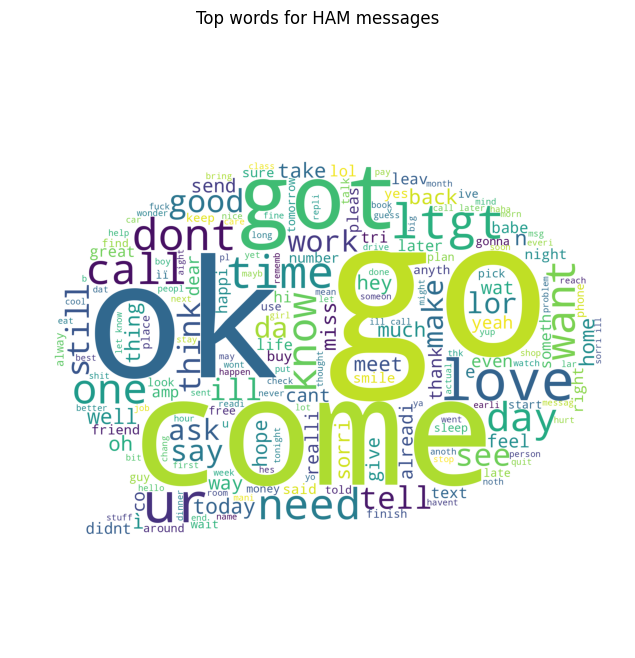

In [18]:
news_mask = np.array(Image.open("../utils/comment.png"))

wc = WordCloud(
    background_color="white",
    max_words=200,
    mask = news_mask
)

wc.generate(" ".join(text for text in df.loc[df["target"] == "ham", "message_clean"]))
plt.figure(figsize=(16, 8))
plt.title("Top words for HAM messages")
plt.imshow(wc)
plt.axis("off")
plt.show()

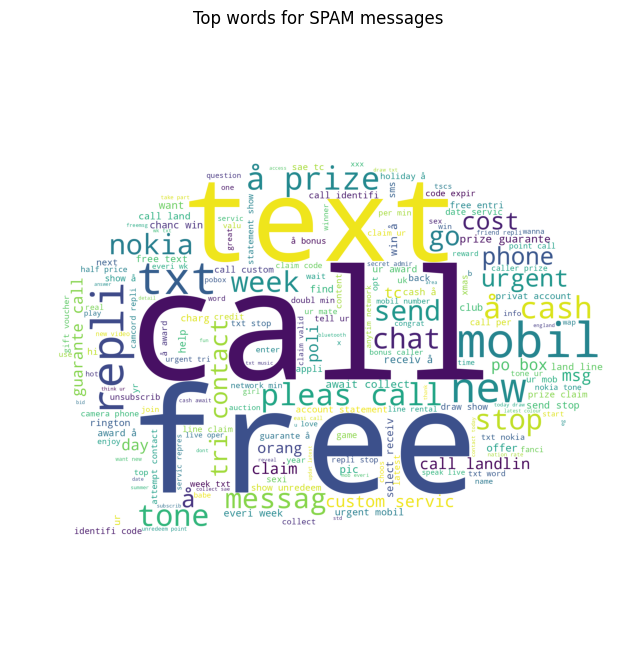

In [21]:
wc.generate(" ".join(text for text in df.loc[df["target"] == "spam", "message_clean"]))

plt.figure(figsize=(16, 8))
plt.title("Top words for SPAM messages")
plt.imshow(wc)
plt.axis("off")
plt.show()

### Vectorization

In [22]:
X = df["message_clean"]
y = df["target_encoded"]

len(X), len(y)

(5572, 5572)

In [23]:
# Split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(y_train), len(X_test), len(y_test)

(4457, 4457, 1115, 1115)

In [24]:
X_train.sample(5)

98      hi wk ok  hol yes bit run forgot hairdress app...
1177                                       nw came hme da
148                                      ki delet contact
2661                                        know dad back
1928    call   tell  call  claim å£ prize  enter ur mo...
Name: message_clean, dtype: object

In [25]:
# Create the Bag Of Words model

cv = CountVectorizer(ngram_range=(1, 3), binary=False)
X_train_dtm = cv.fit_transform(X_train)
X_train_dtm.shape

(4457, 53606)

In [26]:
# cv = CountVectorizer(
#     stop_words="english", ngram_range=(1, 2), min_df=1, max_df=0.95, max_features=500
# )

In [27]:
# Create the TFIDF model

# from sklearn.feature_extraction.text import TfidfVectorizer

# cv = TfidfVectorizer(stop_words="english", ngram_range=(1, 3), binary=False, max_features=4000)
# X_train_dtm = cv.fit_transform(X_train)

In [28]:
X_test_dtm = cv.transform(X_test)
X_test_dtm.shape

(1115, 53606)

In [29]:
import pickle

filename = "spam_tokenizer.pkl"
pickle.dump(cv, open(filename, "wb"))

### Modeling

In [30]:
#Create a Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

# Train the model
nb.fit(X_train_dtm, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [31]:
# from sklearn.ensemble import RandomForestClassifier

# nb = RandomForestClassifier()

# # # Train the model
# nb.fit(X_train_dtm, y_train)

In [32]:
# Make class anf probability predictions
y_pred = nb.predict(X_test_dtm)

In [33]:
# calculate accuracy of class predictions
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

acc, cm

(0.9811659192825112,
 array([[962,   3],
        [ 18, 132]], dtype=int64))

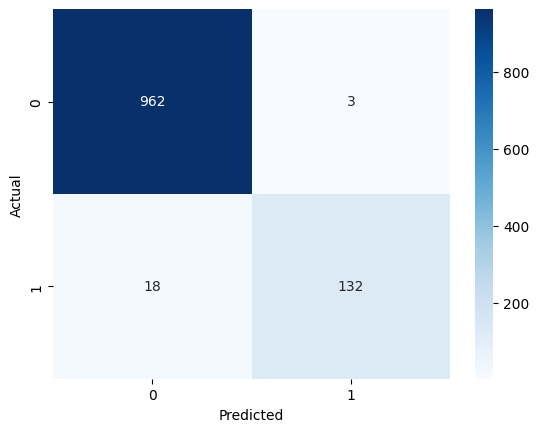

In [34]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       980
           1       0.88      0.98      0.93       135

    accuracy                           0.98      1115
   macro avg       0.94      0.98      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [36]:
# Bag Of Words + MultinomialNB

#               precision    recall  f1-score   support

#            0       1.00      0.98      0.99       980
#            1       0.88      0.98      0.93       135

#     accuracy                           0.98      1115
#    macro avg       0.94      0.98      0.96      1115
# weighted avg       0.98      0.98      0.98      1115

In [37]:
# TF-IDF + Random Forest Classifier

#               precision    recall  f1-score   support

#            0       1.00      0.97      0.99       993
#            1       0.81      1.00      0.90       122

#     accuracy                           0.97      1115
#    macro avg       0.91      0.99      0.94      1115
# weighted avg       0.98      0.97      0.98      1115

In [38]:
import pickle

filename = "spam_classifier.pkl"
pickle.dump(nb, open(filename, "wb"))

In [39]:
load_model = pickle.load(open(filename, "rb"))
y_pred = nb.predict(X_test_dtm)

In [40]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [41]:
acc, cm

(0.9811659192825112,
 array([[962,   3],
        [ 18, 132]], dtype=int64))